# NAVYA — Uncertainty Calibration

This notebook is the single uncertainty step in the pipeline. It uses training women to fit the already-selected model and validation women to calibrate a simple 90% split-conformal prediction interval. The final test women are not accessed here.

## Why uncertainty and support checks?

Menstrual cycle length naturally varies, so a point estimate alone can imply false precision. A conformal interval gives a practical uncertainty range. A model should also not be trusted blindly for recent cycles that were not sufficiently represented in training data.

## 1. Load the locked selection and recreate train/validation women

Multiple windows belong to each simulated woman, so all splits remain woman-wise. The model selection and hyperparameters are read from Notebook 05; this notebook does not tune any model.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

RANDOM_STATE=42
ROOT=Path.cwd().resolve(); ROOT=ROOT if (ROOT/'data').exists() else ROOT.parent
FEATURES=['age_years','menarche_age','height_cm','weight_kg','bmi','sleep_hours','stress_level','exercise_frequency','uses_medication_or_contraceptive','prev_cycle_1','prev_cycle_2','prev_cycle_3','avg_previous_cycle_length','std_previous_cycle_length','prev_period_1','prev_period_2','prev_period_3','avg_previous_period_length']
df=pd.read_csv(ROOT/'processed_data'/'model_ready_dataset.csv')
women=np.random.RandomState(RANDOM_STATE).permutation(np.sort(df.woman_id.unique()))
train=df[df.woman_id.isin(women[:800])].copy(); validation=df[df.woman_id.isin(women[800:900])].copy()
assert not (set(train.woman_id)&set(validation.woman_id))
print(f'Train women/rows: {train.woman_id.nunique()}/{len(train):,}; validation women/rows: {validation.woman_id.nunique()}/{len(validation):,}')
with open(ROOT/'results'/'tuning'/'best_tuned_model.json') as f: selected=json.load(f)
assert selected['model'] == 'XGBRegressor', 'Run Notebook 05 first: uncertainty calibration must use the locked XGBRegressor selection.'
print('Selected model:',selected['model']); print('Best hyperparameters:',selected['best_params']); print('Grouped CV MAE:',selected['best_cv_mae'])

Train women/rows: 800/16,000; validation women/rows: 100/2,000
Selected model: XGBRegressor
Best hyperparameters: {'model__subsample': 0.7, 'model__n_estimators': 250, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
Grouped CV MAE: 1.2334621667861938


## 2. Rebuild the exact locked pipeline

The factory reproduces the selected estimator and train-fitted preprocessing. No validation or test values enter the imputer/scaler fit.

In [2]:
def make_model(name, params):
    classes={'GradientBoostingRegressor':GradientBoostingRegressor,'RandomForestRegressor':RandomForestRegressor,'HistGradientBoostingRegressor':HistGradientBoostingRegressor,'XGBRegressor':XGBRegressor,'SVR':SVR}
    defaults={'random_state':RANDOM_STATE}
    if name=='RandomForestRegressor': defaults['n_jobs']=-1
    if name=='XGBRegressor': defaults.update({'objective':'reg:squarederror','n_jobs':-1})
    defaults.update({key.replace('model__',''):value for key,value in params.items()})
    steps=[('imputer',SimpleImputer(strategy='median'))]
    if name=='SVR': steps.append(('scaler',StandardScaler()))
    return Pipeline(steps+[('model',classes[name](**defaults))])

calibration_model=make_model(selected['model'],selected['best_params'])
calibration_model.fit(train[FEATURES],train.next_cycle_length_days)
validation_predictions=calibration_model.predict(validation[FEATURES])

## 3. Calibrate the 90% split-conformal interval

Absolute validation residuals are used as the calibration set. The finite-sample quantile below produces `q_hat`; supported ML predictions later receive `prediction ± q_hat`.

Calibration rows: 2,000; nominal coverage: 90%; q_hat: 2.204 days


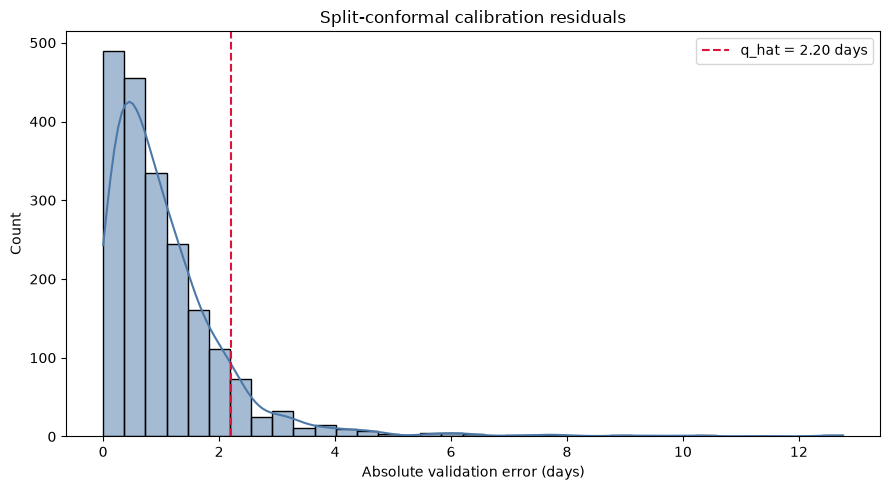

In [3]:
coverage=0.90; alpha=1-coverage
residuals=np.abs(validation.next_cycle_length_days.to_numpy()-validation_predictions)
n=len(residuals); quantile_level=min(np.ceil((n+1)*(1-alpha))/n,1.0)
q_hat=float(np.quantile(residuals,quantile_level,method='higher'))
print(f'Calibration rows: {n:,}; nominal coverage: {coverage:.0%}; q_hat: {q_hat:.3f} days')
plt.figure(figsize=(9,5)); sns.histplot(residuals,bins=35,kde=True,color='#4C78A8'); plt.axvline(q_hat,color='crimson',linestyle='--',label=f'q_hat = {q_hat:.2f} days'); plt.xlabel('Absolute validation error (days)'); plt.title('Split-conformal calibration residuals'); plt.legend(); plt.tight_layout(); plt.show()

## 4. Define the training-supported recent-cycle range

The range is the 1st to 99th percentile of all three previous-cycle values from training women only. It is intentionally broad so normal variation is accepted, while clearly unrepresented histories are marked low-confidence.

Supported recent-cycle range: 17.0 to 39.0 days


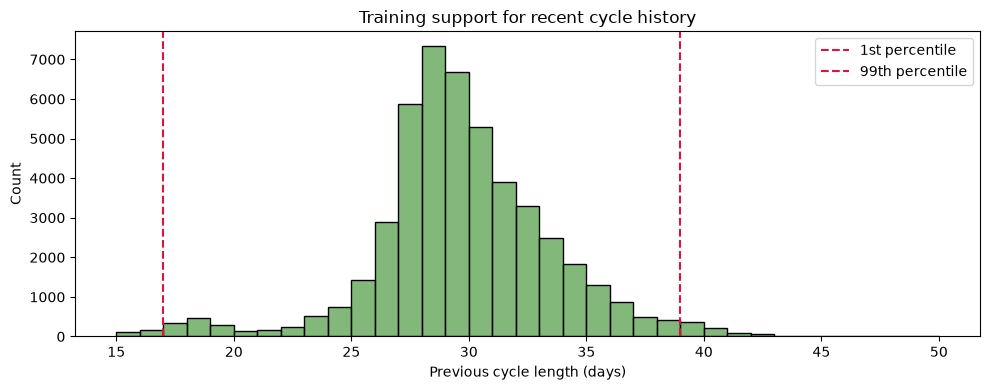

In [4]:
support_values=train[['prev_cycle_1','prev_cycle_2','prev_cycle_3']].to_numpy().ravel()
supported_lower=float(np.percentile(support_values,1)); supported_upper=float(np.percentile(support_values,99))
print(f'Supported recent-cycle range: {supported_lower:.1f} to {supported_upper:.1f} days')
plt.figure(figsize=(10,4)); sns.histplot(support_values,bins=35,color='#59A14F'); plt.axvline(supported_lower,color='crimson',linestyle='--',label='1st percentile'); plt.axvline(supported_upper,color='crimson',linestyle='--',label='99th percentile'); plt.xlabel('Previous cycle length (days)'); plt.title('Training support for recent cycle history'); plt.legend(); plt.tight_layout(); plt.show()

## 5. Save calibration metadata and the matching model

The fitted 800-woman pipeline is saved with its preprocessing. Notebook 09 uses this exact pipeline for final test predictions, and Notebook 10 exports the same pipeline. This keeps split-conformal calibration mathematically consistent.

In [5]:
artifact={'uncertainty_method':'split_conformal','coverage':coverage,'q_hat_days':q_hat,'calibration_rows':n,'quantile_level':float(quantile_level),'supported_cycle_lower_bound':supported_lower,'supported_cycle_upper_bound':supported_upper,'support_rule':'1st to 99th percentile of training previous-cycle values','selected_model':selected['model'],'hyperparameters':selected['best_params'],'model_training_women':int(train.woman_id.nunique())}
out=ROOT/'results'/'metrics'; models_dir=ROOT/'models'; out.mkdir(parents=True,exist_ok=True); models_dir.mkdir(exist_ok=True)
with open(out/'uncertainty_calibration.json','w') as f: json.dump(artifact,f,indent=2)
calibrated_model_path=models_dir/'calibrated_cycle_length_model.joblib'; joblib.dump(calibration_model,calibrated_model_path)
display(pd.DataFrame([artifact]).drop(columns=['hyperparameters']))
print('Saved:',out/'uncertainty_calibration.json'); print('Saved matching calibrated pipeline:',calibrated_model_path)

,uncertainty_method,coverage,q_hat_days,calibration_rows,quantile_level,supported_cycle_lower_bound,supported_cycle_upper_bound,support_rule,selected_model,model_training_women
0,split_conformal,0.9,2.20421,2000,0.9005,17.0,39.0,1st to 99th percentile of training previous-cy...,XGBRegressor,800


Saved: E:\NAVYA_MODEL\saksham\results\metrics\uncertainty_calibration.json
Saved matching calibrated pipeline: E:\NAVYA_MODEL\saksham\models\calibrated_cycle_length_model.joblib


## Interpretation

This is a simple, explainable uncertainty mechanism—not a second ML model. A supported three-cycle history receives an ML prediction with a 90% interval; an extreme outside-support history should use the labelled history-average fallback in Notebook 10.